# Interpretation

SHAP values from the fitted LightGBM — which features move risk and in which direction. A random sample drives the beeswarm; global importance is the mean absolute SHAP.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
import shap
from src.data import load_selected

INTERIM = Path("../data/interim")
X, y = load_selected()
X.shape

(307511, 441)

## Fit

In [2]:
model = lgb.LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                           n_jobs=-1, verbose=-1).fit(X, y)

## SHAP summary

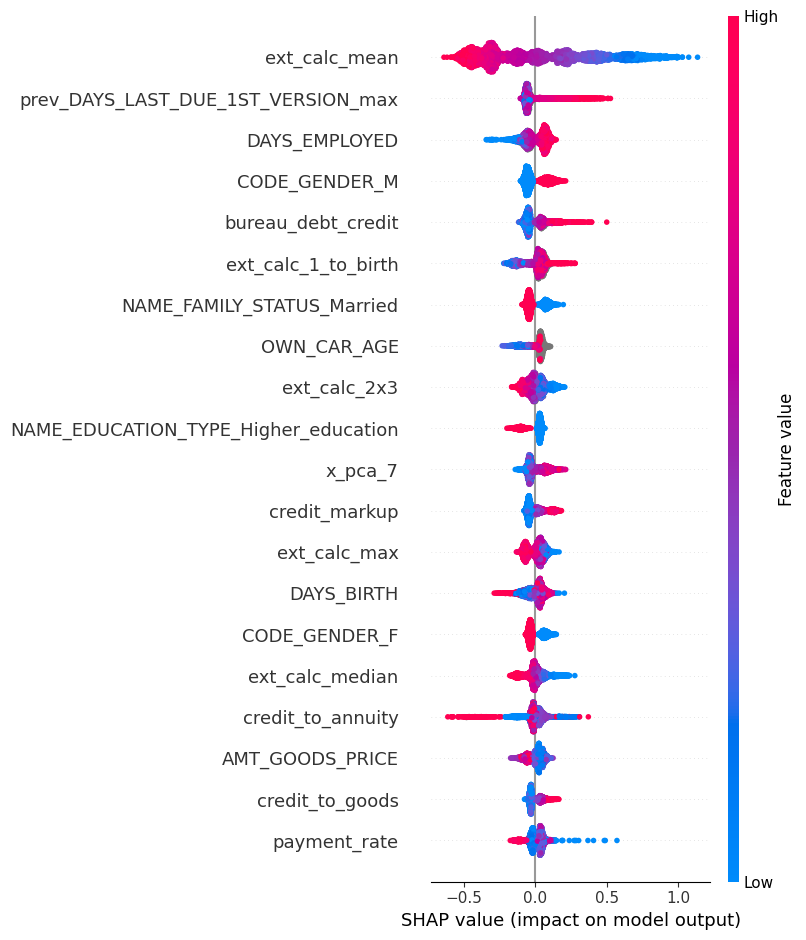

In [3]:
samp = X.sample(5000, random_state=42)
sv = model.booster_.predict(samp, pred_contrib=True)[:, :-1]
shap.summary_plot(sv, samp, max_display=20, show=True)

## Global importance

In [4]:
imp = pd.Series(np.abs(sv).mean(0), index=samp.columns).sort_values(ascending=False)
imp.head(20)

ext_calc_mean                           0.342320
prev_DAYS_LAST_DUE_1ST_VERSION_max      0.083049
DAYS_EMPLOYED                           0.068043
CODE_GENDER_M                           0.067510
bureau_debt_credit                      0.062926
ext_calc_1_to_birth                     0.060032
NAME_FAMILY_STATUS_Married              0.056936
OWN_CAR_AGE                             0.052166
ext_calc_2x3                            0.051450
NAME_EDUCATION_TYPE_Higher_education    0.051084
x_pca_7                                 0.050663
credit_markup                           0.049599
ext_calc_max                            0.048693
DAYS_BIRTH                              0.048512
CODE_GENDER_F                           0.047324
ext_calc_median                         0.047094
credit_to_annuity                       0.046959
AMT_GOODS_PRICE                         0.040690
credit_to_goods                         0.038821
payment_rate                            0.038398
dtype: float64

## Top feature effect

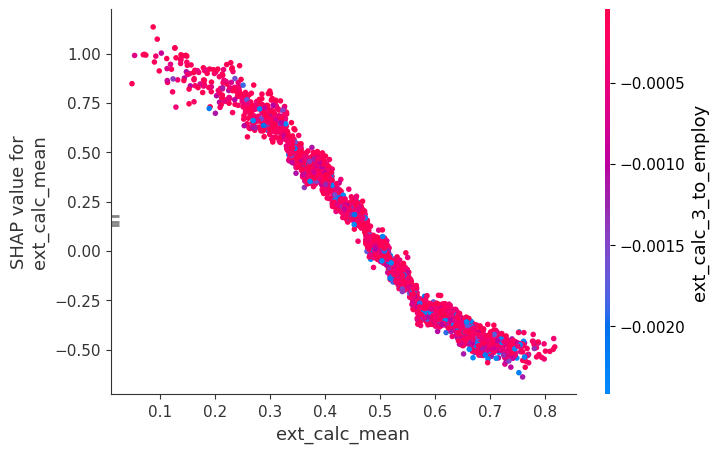

In [5]:
shap.dependence_plot(imp.index[0], sv, samp, show=True)

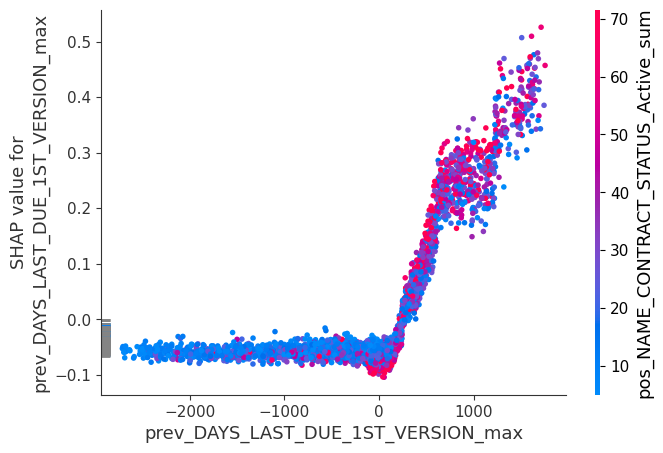

In [6]:
shap.dependence_plot(imp.index[1], sv, samp, show=True)

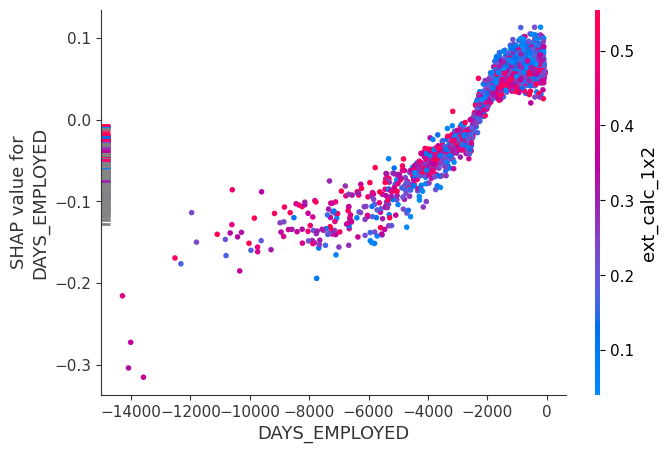

In [7]:
shap.dependence_plot(imp.index[2], sv, samp, show=True)

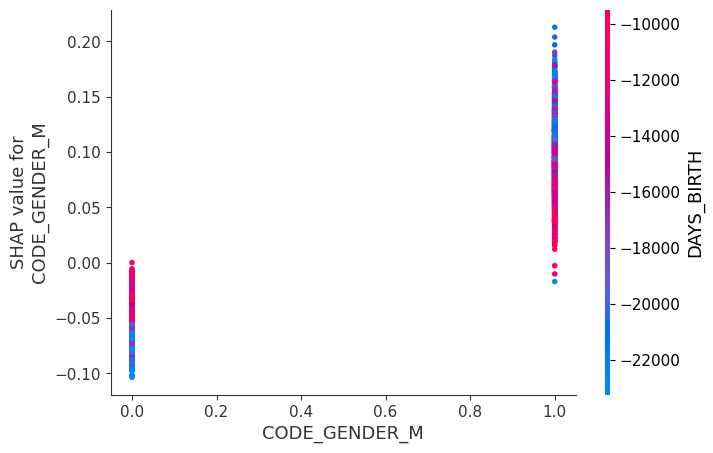

In [8]:
shap.dependence_plot(imp.index[3], sv, samp, show=True)

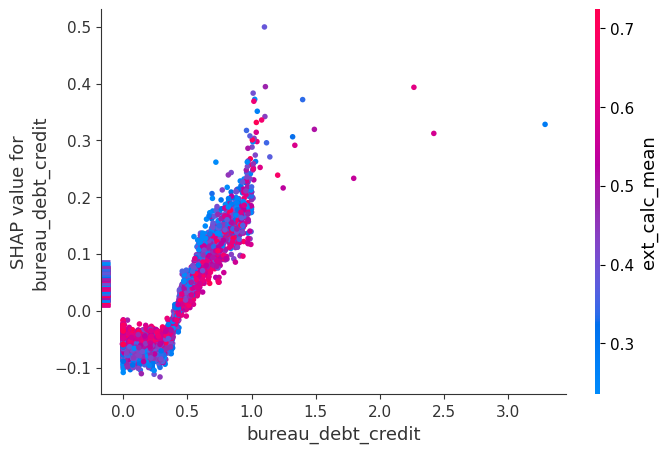

In [9]:
shap.dependence_plot(imp.index[4], sv, samp, show=True)

## Bought vs built — SHAP attribution

Summing mean absolute SHAP by source family gives a bought-vs-built split that is faithful to how the model actually uses each feature, unlike gain (which is biased toward high-cardinality features).

In [10]:
def fam(c):
    cl = c.lower()
    if "ext_source" in cl or cl.startswith("ext_calc_"): return "Purchased scores (bought)"
    if cl.startswith(("bureau", "bb_")): return "Credit bureau"
    if cl.startswith("prev"): return "Prior applications"
    if cl.startswith("pos"): return "POS / cash loans"
    if cl.startswith("ins"): return "Installment history"
    if cl.startswith("cc"): return "Credit card"
    if cl.startswith(("x_pca", "x_kmeans", "x_ae")): return "Learned features"
    if cl.startswith("x_"): return "Cross-table"
    return "Application form"

fam_imp = pd.Series(np.abs(sv).mean(0), index=samp.columns).groupby(samp.columns.map(fam)).sum()
fam_share = (fam_imp / fam_imp.sum()).sort_values(ascending=False)
bought = fam_share.filter(like="bought").sum()
print(f"SHAP-based split -> bought {bought:.0%} | built {1 - bought:.0%}   (gain-based was 38 / 62)")
fam_share.round(3)

SHAP-based split -> bought 18% | built 82%   (gain-based was 38 / 62)


Application form             0.282
Purchased scores (bought)    0.182
Credit bureau                0.127
Prior applications           0.112
Installment history          0.095
Cross-table                  0.090
Learned features             0.043
POS / cash loans             0.037
Credit card                  0.031
dtype: float64

## Do the purchased scores matter more for thin files?

The thesis says the external scores should carry the most weight exactly where the lender's own data is sparse. Split the sample into thin vs thick files (by how many internal features are populated) and compare how much the model leans on the purchased scores in each.

In [11]:
ext_cols = [c for c in samp.columns if "ext_source" in c.lower() or c.lower().startswith("ext_calc_")]
internal_cols = [c for c in samp.columns if c not in ext_cols]
thickness = samp[internal_cols].notna().sum(axis=1)
thin = (thickness < thickness.median()).to_numpy()
ext_idx = [samp.columns.get_loc(c) for c in ext_cols]
ext_shap = np.abs(sv[:, ext_idx]).sum(axis=1)   # total purchased-score SHAP magnitude per applicant

print("total |SHAP| from purchased scores per applicant")
print(f"  thin files   {ext_shap[thin].mean():.3f}")
print(f"  thick files  {ext_shap[~thin].mean():.3f}")
print(f"  ratio        {ext_shap[thin].mean() / ext_shap[~thin].mean():.2f}x  (>1 means the scores matter more when our data is sparse)")

total |SHAP| from purchased scores per applicant
  thin files   0.707
  thick files  0.662
  ratio        1.07x  (>1 means the scores matter more when our data is sparse)


## Permutation importance (cross-check)

SHAP measures how the model uses a feature; permutation importance measures how much predictive accuracy actually depends on it (AUC drop when the feature is shuffled on held-out rows). Shuffling all purchased scores together gives a permutation-based version of what they are worth.

In [12]:
from sklearn.metrics import roc_auc_score
rng = np.random.default_rng(0)
hold = X.sample(60000, random_state=1); yh = y.loc[hold.index]
base = roc_auc_score(yh, model.predict_proba(hold)[:, 1])

def drop(cols):
    Xp = hold.copy()
    for c in cols:
        Xp[c] = rng.permutation(Xp[c].to_numpy())
    return base - roc_auc_score(yh, model.predict_proba(Xp)[:, 1])

ext_all = [c for c in X.columns if "ext_source" in c.lower() or c.lower().startswith("ext_calc_")]
print(f"base AUC {base:.4f}")
print(f"all purchased scores shuffled:  -{drop(ext_all):.4f} AUC")
pd.DataFrame([{"feature": c, "auc_drop": round(drop([c]), 4)} for c in imp.index[:10]]).sort_values("auc_drop", ascending=False)

base AUC 0.8719
all purchased scores shuffled:  -0.0614 AUC


,feature,auc_drop
0,ext_calc_mean,0.0168
1,prev_DAYS_LAST_DUE_1ST_VERSION_max,0.0051
5,ext_calc_1_to_birth,0.0032
3,CODE_GENDER_M,0.0020
6,NAME_FAMILY_STATUS_Married,0.0020
7,OWN_CAR_AGE,0.0017
4,bureau_debt_credit,0.0013
2,DAYS_EMPLOYED,0.0012
9,NAME_EDUCATION_TYPE_Higher_education,0.0009
8,ext_calc_2x3,0.0007
